# Prediction Script - Health Score Prediction

This notebook loads the trained Stacking Ensemble model and makes predictions on new data.

**Input**: `transformed_model_data.xlsx`  
**Output**: `model_data.xlsx` (with predictions and all input parameters)

In [17]:
# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
# Load the trained model and preprocessing objects
models_dir = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\models")

# Load stacking ensemble model
stacker = joblib.load(models_dir / "improved_healthscore_stacker.joblib")
print("✓ Loaded: Stacking Ensemble Model")

# Load scaler
scaler = joblib.load(models_dir / "improved_healthscore_scaler.joblib")
print("✓ Loaded: RobustScaler")

# Load feature selector
feature_selector = joblib.load(models_dir / "improved_healthscore_feature_selector.joblib")
print("✓ Loaded: Feature Selector")

# Load feature names
with open(models_dir / "improved_healthscore_feature_names.json", 'r') as f:
    selected_feature_names = json.load(f)
print(f"✓ Loaded: {len(selected_feature_names)} feature names")

print("\nAll models and preprocessing objects loaded successfully!")

✓ Loaded: Stacking Ensemble Model
✓ Loaded: RobustScaler
✓ Loaded: Feature Selector
✓ Loaded: 66 feature names

All models and preprocessing objects loaded successfully!


In [19]:
# Load the input data
input_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\model.xlsx")
df_input = pd.read_excel(input_path, engine='openpyxl')

print(f"✓ Loaded input data: {df_input.shape[0]:,} rows × {df_input.shape[1]} columns")
print(f"\nColumns in input data:")
for i, col in enumerate(df_input.columns, 1):
    print(f"  {i:2d}. {col}")

df_input.head()

✓ Loaded input data: 24,874 rows × 11 columns

Columns in input data:
   1. industry
   2. company_size
   3. arr
   4. mrr
   5. renewal_stage
   6. sentiment_score
   7. sentiment_category
   8. licenses_total
   9. licenses_used
  10. utilization_percentage
  11. total_relationship_signal


,industry,company_size,arr,mrr,renewal_stage,sentiment_score,sentiment_category,licenses_total,licenses_used,utilization_percentage,total_relationship_signal
0,Technology,Small,156049,13004.08,t90,0.3353,neutral,20,15,79,67.069227
1,Healthcare,Medium,517493,43124.42,t90,0.8553,positive,30,23,79,85.707851
2,Analytics,Large,64898,5408.17,t90,-0.4162,negative,20,14,73,47.894085
3,Healthcare,Medium,43003,3583.58,t90,0.3132,neutral,20,14,73,46.408622
4,Enterprise,Medium,100005,8333.75,t30,0.9937,very_positive,50,33,66,57.315549


In [20]:
# Step 1: Advanced Feature Engineering (replicate from EDA notebook Cell 18)
print("=" * 60)
print("STEP 1: Advanced Feature Engineering")
print("=" * 60)

# Make a copy to avoid modifying original
X_engineered = df_input.copy()

# Load original data for industry/size aggregations (if needed)
original_data_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\customer_data_25000.xlsx")
if original_data_path.exists():
    df_original = pd.read_excel(original_data_path, sheet_name="Accounts", engine='openpyxl')
    print("✓ Loaded original data for aggregations")
else:
    # Use input data for aggregations (fallback)
    df_original = df_input.copy()
    print("⚠️  Using input data for aggregations (original data not found)")

# 1. Financial Features (ratios and transformations)
X_engineered['arr_per_license'] = X_engineered['arr'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['mrr_per_license'] = X_engineered['mrr'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['arr_mrr_ratio'] = X_engineered['arr'] / (X_engineered['mrr'].replace(0, 1) * 12)
X_engineered['total_financial_value'] = np.log1p(X_engineered['arr'] + X_engineered['mrr'])

# 2. Utilization Features
X_engineered['license_utilization_ratio'] = X_engineered['licenses_used'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['utilization_efficiency'] = X_engineered['utilization_percentage'] * X_engineered['license_utilization_ratio']
X_engineered['underutilized_licenses'] = X_engineered['licenses_total'] - X_engineered['licenses_used']
X_engineered['utilization_gap'] = 100 - X_engineered['utilization_percentage']

# 3. Sentiment Features
X_engineered['sentiment_positive'] = (X_engineered['sentiment_score'] > 0).astype(int)
X_engineered['sentiment_strong_positive'] = (X_engineered['sentiment_score'] > 0.5).astype(int)
X_engineered['sentiment_negative'] = (X_engineered['sentiment_score'] < 0).astype(int)

# 4. Interaction Features
X_engineered['arr_sentiment_interaction'] = X_engineered['arr'] * (X_engineered['sentiment_score'] + 1)
X_engineered['utilization_sentiment'] = X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['financial_utilization'] = X_engineered['total_financial_value'] * X_engineered['utilization_percentage']
X_engineered['license_sentiment'] = X_engineered['licenses_total'] * (X_engineered['sentiment_score'] + 1)

# 5. Company Size Encoding (Ordinal)
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}
X_engineered['company_size_encoded'] = X_engineered['company_size'].map(size_mapping)

# 6. Renewal Stage Encoding (Time to renewal)
renewal_mapping = {'t90': 90, 't60': 60, 't30': 30}
X_engineered['renewal_days'] = X_engineered['renewal_stage'].map(renewal_mapping)
X_engineered['renewal_urgency'] = 1 / X_engineered['renewal_days']

# 7. Industry Grouping (Reduce dimensionality)
industry_counts = X_engineered['industry'].value_counts()
common_industries = industry_counts[industry_counts >= 1000].index if len(industry_counts) > 0 else []
X_engineered['industry_grouped'] = X_engineered['industry'].apply(
    lambda x: x if x in common_industries else 'Other'
)

# 8. Composite Scores
X_engineered['engagement_score'] = (
    X_engineered['utilization_percentage'] * 0.5 + 
    X_engineered['license_utilization_ratio'] * 50
)
X_engineered['value_score'] = (
    (X_engineered['arr'] / X_engineered['arr'].max()) * 50 + 
    (X_engineered['sentiment_score'] + 1) * 25
)

# 9. Advanced Polynomial Features
X_engineered['arr_squared'] = X_engineered['arr'] ** 2
X_engineered['mrr_squared'] = X_engineered['mrr'] ** 2
X_engineered['utilization_squared'] = X_engineered['utilization_percentage'] ** 2
X_engineered['sentiment_squared'] = X_engineered['sentiment_score'] ** 2

# 10. Cross-Product Features
X_engineered['arr_utilization_cross'] = X_engineered['arr'] * X_engineered['utilization_percentage']
X_engineered['mrr_utilization_cross'] = X_engineered['mrr'] * X_engineered['utilization_percentage']
X_engineered['arr_license_cross'] = X_engineered['arr'] * X_engineered['licenses_total']
X_engineered['mrr_license_cross'] = X_engineered['mrr'] * X_engineered['licenses_total']
X_engineered['utilization_license_cross'] = X_engineered['utilization_percentage'] * X_engineered['licenses_total']

# 11. Ratio-based Features
X_engineered['arr_to_utilization'] = X_engineered['arr'] / (X_engineered['utilization_percentage'] + 1)
X_engineered['mrr_to_utilization'] = X_engineered['mrr'] / (X_engineered['utilization_percentage'] + 1)
X_engineered['sentiment_to_utilization'] = (X_engineered['sentiment_score'] + 1) / (X_engineered['utilization_percentage'] + 1)

# 12. Log Transformations
X_engineered['log_arr'] = np.log1p(X_engineered['arr'])
X_engineered['log_mrr'] = np.log1p(X_engineered['mrr'])
X_engineered['log_licenses_total'] = np.log1p(X_engineered['licenses_total'])
X_engineered['log_licenses_used'] = np.log1p(X_engineered['licenses_used'])

# 13. Normalized Features
X_engineered['arr_normalized'] = X_engineered['arr'] / X_engineered['arr'].max()
X_engineered['mrr_normalized'] = X_engineered['mrr'] / X_engineered['mrr'].max()
X_engineered['utilization_normalized'] = X_engineered['utilization_percentage'] / 100

# 14. Industry-Specific Aggregations (from original data)
industry_stats = df_original.groupby('industry').agg({
    'arr': ['mean', 'std', 'median'],
    'mrr': ['mean', 'std'],
    'utilization_percentage': ['mean', 'std'],
    'sentiment_score': ['mean', 'std']
}).reset_index()
industry_stats.columns = ['industry', 'ind_arr_mean', 'ind_arr_std', 'ind_arr_median', 
                          'ind_mrr_mean', 'ind_mrr_std', 'ind_util_mean', 'ind_util_std',
                          'ind_sent_mean', 'ind_sent_std']
X_engineered = X_engineered.merge(industry_stats, on='industry', how='left')

# 15. Company Size Aggregations
size_stats = df_original.groupby('company_size').agg({
    'arr': ['mean', 'std'],
    'mrr': ['mean', 'std'],
    'utilization_percentage': ['mean']
}).reset_index()
size_stats.columns = ['company_size', 'size_arr_mean', 'size_arr_std', 
                      'size_mrr_mean', 'size_mrr_std', 'size_util_mean']
X_engineered = X_engineered.merge(size_stats, on='company_size', how='left')

# 16. Relative Position Features
X_engineered['arr_vs_industry'] = X_engineered['arr'] / (X_engineered['ind_arr_mean'] + 1)
X_engineered['mrr_vs_industry'] = X_engineered['mrr'] / (X_engineered['ind_mrr_mean'] + 1)
X_engineered['util_vs_industry'] = X_engineered['utilization_percentage'] / (X_engineered['ind_util_mean'] + 1)
X_engineered['sent_vs_industry'] = X_engineered['sentiment_score'] / (X_engineered['ind_sent_mean'] + 1)

# 17. Triple Interactions
X_engineered['arr_util_sent_triple'] = X_engineered['arr'] * X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['mrr_util_sent_triple'] = X_engineered['mrr'] * X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['arr_license_util_triple'] = X_engineered['arr'] * X_engineered['licenses_total'] * X_engineered['utilization_percentage']

print(f"✓ Created {len(X_engineered.columns)} features (including engineered)")
print(f"✓ Original features: {len(df_input.columns)}")
print(f"✓ New engineered features: {len(X_engineered.columns) - len(df_input.columns)}")

STEP 1: Advanced Feature Engineering
✓ Loaded original data for aggregations
✓ Created 72 features (including engineered)
✓ Original features: 11
✓ New engineered features: 61


In [21]:
# Step 2: Feature Preparation and Encoding (replicate from EDA notebook Cell 20)
print("=" * 60)
print("STEP 2: Feature Preparation and Encoding")
print("=" * 60)

# Remove target column if it exists (we don't need it for prediction)
X_features = X_engineered.drop(columns=['health_score'], errors='ignore')

# Handle missing values
numeric_cols = X_features.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    X_features[col].fillna(X_features[col].median(), inplace=True)

categorical_cols = X_features.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = X_features[col].mode()
    if len(mode_val) > 0:
        X_features[col].fillna(mode_val[0], inplace=True)
    else:
        X_features[col].fillna('Unknown', inplace=True)

# One-hot encode categorical variables
categorical_to_encode = ['industry', 'industry_grouped', 'company_size', 
                        'renewal_stage', 'sentiment_category']
categorical_to_encode = [c for c in categorical_to_encode if c in X_features.columns]

X_encoded = pd.get_dummies(
    X_features, 
    columns=categorical_to_encode, 
    drop_first=True,
    prefix_sep='_'
)

# Remove any remaining non-numeric columns
X_encoded = X_encoded.select_dtypes(include=[np.number])

print(f"✓ Final feature matrix: {X_encoded.shape[1]} features")
print(f"✓ Sample size: {len(X_encoded):,} rows")

STEP 2: Feature Preparation and Encoding
✓ Final feature matrix: 67 features
✓ Sample size: 24,874 rows


In [22]:
# Step 3: Feature Selection (using saved selector)
print("=" * 60)
print("STEP 3: Feature Selection")
print("=" * 60)

# Ensure all required features exist
missing_features = set(selected_feature_names) - set(X_encoded.columns)
if missing_features:
    print(f"⚠️  Warning: {len(missing_features)} features missing. Adding with zeros:")
    for feat in missing_features:
        print(f"  - {feat}")
        X_encoded[feat] = 0

# Ensure feature order matches training
X_selected = X_encoded[selected_feature_names].copy()

# Apply feature selector transformation
X_selected_transformed = feature_selector.transform(X_selected)

# Convert back to DataFrame with correct feature names
X_selected_df = pd.DataFrame(
    X_selected_transformed, 
    columns=selected_feature_names,
    index=X_encoded.index
)

print(f"✓ Selected {len(selected_feature_names)} features")
print(f"✓ Feature matrix shape: {X_selected_df.shape}")

STEP 3: Feature Selection
✓ Selected 66 features
✓ Feature matrix shape: (24874, 66)


In [23]:
# Step 4: Scaling (using saved scaler)
print("=" * 60)
print("STEP 4: Scaling")
print("=" * 60)

X_scaled = scaler.transform(X_selected_df)
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=selected_feature_names,
    index=X_selected_df.index
)

print(f"✓ Scaled feature matrix: {X_scaled_df.shape}")

STEP 4: Scaling
✓ Scaled feature matrix: (24874, 66)


In [24]:
# Step 5: Make Predictions
print("=" * 60)
print("STEP 5: Making Predictions")
print("=" * 60)

predictions = stacker.predict(X_scaled_df)

print(f"✓ Predictions completed for {len(predictions):,} rows")
print(f"\nPrediction Statistics:")
print(f"  Min:  {predictions.min():.2f}")
print(f"  Max:  {predictions.max():.2f}")
print(f"  Mean: {predictions.mean():.2f}")
print(f"  Std:  {predictions.std():.2f}")

# Add predictions to the original dataframe
df_output = df_input.drop(columns=['health_score'], errors='ignore').copy()
df_output['predicted_health_score'] = predictions

print(f"\n✓ Predictions added to output dataframe")
print(f"✓ Output will contain {len(df_output.columns)} columns (input columns + prediction)")


STEP 5: Making Predictions
✓ Predictions completed for 24,874 rows

Prediction Statistics:
  Min:  31.81
  Max:  92.51
  Mean: 70.19
  Std:  16.16

✓ Predictions added to output dataframe
✓ Output will contain 12 columns (input columns + prediction)


STEP 5.5: Visualization

⚠️  No 'health_score' in input data - showing prediction distribution only


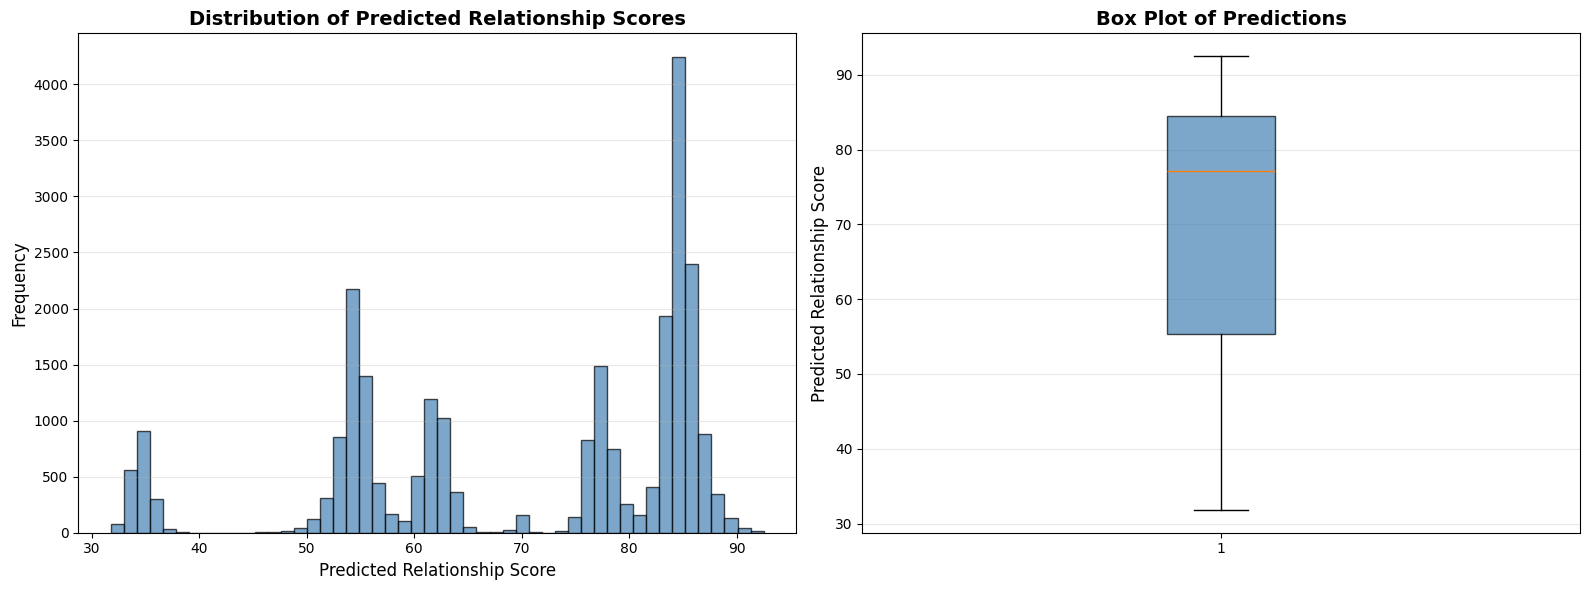


✓ Visualization created: Prediction distribution


In [25]:
# Step 5.5: Visualization - Compare Actual vs Predicted (if available)
print("=" * 60)
print("STEP 5.5: Visualization")
print("=" * 60)

# Check if health_score exists in original input data
if 'health_score' in df_input.columns:
    actual = df_input['health_score'].values
    predicted = predictions
    
    # Calculate metrics
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    import numpy as np
    
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    print(f"\nModel Performance Metrics:")
    print(f"  R² Score:  {r2:.4f}")
    print(f"  MAE:       {mae:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Scatter plot - Actual vs Predicted
    axes[0].scatter(actual, predicted, alpha=0.5, s=20, color='steelblue')
    axes[0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], 
                'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Relationship Score (health_score)', fontsize=12)
    axes[0].set_ylabel('Predicted Relationship Score', fontsize=12)
    axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot 2: Residual plot
    residuals = actual - predicted
    axes[1].scatter(predicted, residuals, alpha=0.5, s=20, color='coral')
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Relationship Score', fontsize=12)
    axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization created: Actual vs Predicted comparison")
else:
    # If no actual values, just show prediction distribution
    print("\n⚠️  No 'health_score' in input data - showing prediction distribution only")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Histogram of predictions
    axes[0].hist(predictions, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Predicted Relationship Score', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Predicted Relationship Scores', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Box plot
    axes[1].boxplot(predictions, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[1].set_ylabel('Predicted Relationship Score', fontsize=12)
    axes[1].set_title('Box Plot of Predictions', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization created: Prediction distribution")


In [26]:
# Step 6: Save Results to Excel
print("=" * 60)
print("STEP 6: Saving Results")
print("=" * 60)

output_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

try:
    df_output.to_excel(output_path, index=False, engine='openpyxl')
    print(f"✓ Success! Results saved to: {output_path}")
    print(f"✓ Total rows: {len(df_output):,}")
    print(f"✓ Total columns: {len(df_output.columns)}")
    print(f"\nColumns in output file:")
    for i, col in enumerate(df_output.columns, 1):
        print(f"  {i:2d}. {col}")
except Exception as e:
    print(f"❌ Error saving to Excel: {e}")

print("\n" + "=" * 60)
print("PREDICTION COMPLETE!")
print("=" * 60)

STEP 6: Saving Results
✓ Success! Results saved to: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx
✓ Total rows: 24,874
✓ Total columns: 12

Columns in output file:
   1. industry
   2. company_size
   3. arr
   4. mrr
   5. renewal_stage
   6. sentiment_score
   7. sentiment_category
   8. licenses_total
   9. licenses_used
  10. utilization_percentage
  11. total_relationship_signal
  12. predicted_health_score

PREDICTION COMPLETE!


In [27]:
# Diagnostic: Why are there 3 spikes in the distribution?
print("=" * 60)
print("DIAGNOSTIC: Analyzing 3 Spikes in Distribution")
print("=" * 60)

# Load data
data_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx")
if not data_path.exists():
    print(f"⚠️  File not found: {data_path}")
    print("   Please run the prediction cells above first to generate the predictions file.")
    print("   This diagnostic cell requires the output from Step 6 (Saving Results).")
    df_diag = None
else:
    df_diag = pd.read_excel(data_path, engine='openpyxl')
    print(f"✓ Loaded data from: {data_path}")

if df_diag is None:
    print("\n❌ Cannot proceed with diagnostic analysis - file not found.")
elif 'health_score' in df_diag.columns and 'predicted_health_score' in df_diag.columns:
    # Analyze by renewal_stage (most likely cause of 3 spikes)
    if 'renewal_stage' in df_diag.columns:
        print("\n📊 Analysis by Renewal Stage:")
        print("-" * 60)
        
        for stage in sorted(df_diag['renewal_stage'].unique()):
            stage_data = df_diag[df_diag['renewal_stage'] == stage]
            actual_stage = stage_data['health_score'].values
            predicted_stage = stage_data['predicted_health_score'].values
            
            print(f"\n{stage.upper()}:")
            print(f"  Count: {len(stage_data):,} rows")
            print(f"  Actual - Mean: {actual_stage.mean():.2f}, Std: {actual_stage.std():.2f}")
            print(f"  Actual - Range: [{actual_stage.min():.2f}, {actual_stage.max():.2f}]")
            print(f"  Predicted - Mean: {predicted_stage.mean():.2f}, Std: {predicted_stage.std():.2f}")
            print(f"  Predicted - Range: [{predicted_stage.min():.2f}, {predicted_stage.max():.2f}]")
        
        # Visualization: Distribution by renewal_stage
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Actual distribution by renewal_stage
        for stage in sorted(df_diag['renewal_stage'].unique()):
            stage_data = df_diag[df_diag['renewal_stage'] == stage]
            axes[0, 0].hist(stage_data['health_score'], 
                          bins=30, alpha=0.6, label=f'{stage}', edgecolor='black')
        axes[0, 0].set_xlabel('Actual Relationship Score', fontsize=12)
        axes[0, 0].set_ylabel('Frequency', fontsize=12)
        axes[0, 0].set_title('Actual Distribution by Renewal Stage', fontsize=14, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        
        # Plot 2: Predicted distribution by renewal_stage
        for stage in sorted(df_diag['renewal_stage'].unique()):
            stage_data = df_diag[df_diag['renewal_stage'] == stage]
            axes[0, 1].hist(stage_data['predicted_health_score'], 
                          bins=30, alpha=0.6, label=f'{stage}', edgecolor='black')
        axes[0, 1].set_xlabel('Predicted Relationship Score', fontsize=12)
        axes[0, 1].set_ylabel('Frequency', fontsize=12)
        axes[0, 1].set_title('Predicted Distribution by Renewal Stage', fontsize=14, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # Plot 3: Box plot comparison
        box_data_actual = [df_diag[df_diag['renewal_stage'] == stage]['health_score'].values 
                          for stage in sorted(df_diag['renewal_stage'].unique())]
        axes[1, 0].boxplot(box_data_actual, labels=sorted(df_diag['renewal_stage'].unique()), 
                          patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
        axes[1, 0].set_ylabel('Actual Relationship Score', fontsize=12)
        axes[1, 0].set_xlabel('Renewal Stage', fontsize=12)
        axes[1, 0].set_title('Actual Scores by Renewal Stage', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        box_data_pred = [df_diag[df_diag['renewal_stage'] == stage]['predicted_health_score'].values 
                        for stage in sorted(df_diag['renewal_stage'].unique())]
        axes[1, 1].boxplot(box_data_pred, labels=sorted(df_diag['renewal_stage'].unique()), 
                          patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.7))
        axes[1, 1].set_ylabel('Predicted Relationship Score', fontsize=12)
        axes[1, 1].set_xlabel('Renewal Stage', fontsize=12)
        axes[1, 1].set_title('Predicted Scores by Renewal Stage', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ The 3 spikes are likely caused by the 3 renewal stages (t90, t60, t30)")
        print("  Each stage has different relationship score ranges, creating distinct peaks.")
    
    # Also check company_size if needed
    if 'company_size' in df_diag.columns:
        print("\n📊 Analysis by Company Size:")
        print("-" * 60)
        for size in ['Small', 'Medium', 'Large', 'Enterprise']:
            if size in df_diag['company_size'].values:
                size_data = df_diag[df_diag['company_size'] == size]
                print(f"{size}: Mean Actual = {size_data['health_score'].mean():.2f}, "
                      f"Mean Predicted = {size_data['predicted_health_score'].mean():.2f}")
else:
    print("\n⚠️  Required columns not found for diagnostic analysis")


DIAGNOSTIC: Analyzing 3 Spikes in Distribution
✓ Loaded data from: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx

⚠️  Required columns not found for diagnostic analysis


FINAL VISUALIZATION: Actual vs Predicted Comparison
✓ Loaded data from: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx
✓ Loaded data from: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx
✓ Total rows: 24,874
✓ Columns: ['industry', 'company_size', 'arr', 'mrr', 'renewal_stage', 'sentiment_score', 'sentiment_category', 'licenses_total', 'licenses_used', 'utilization_percentage', 'total_relationship_signal', 'predicted_health_score']

⚠️  Only predicted values available (no actual values for comparison)

Prediction Statistics:
  Min:  31.81
  Max:  92.51
  Mean: 70.19
  Std:  16.16


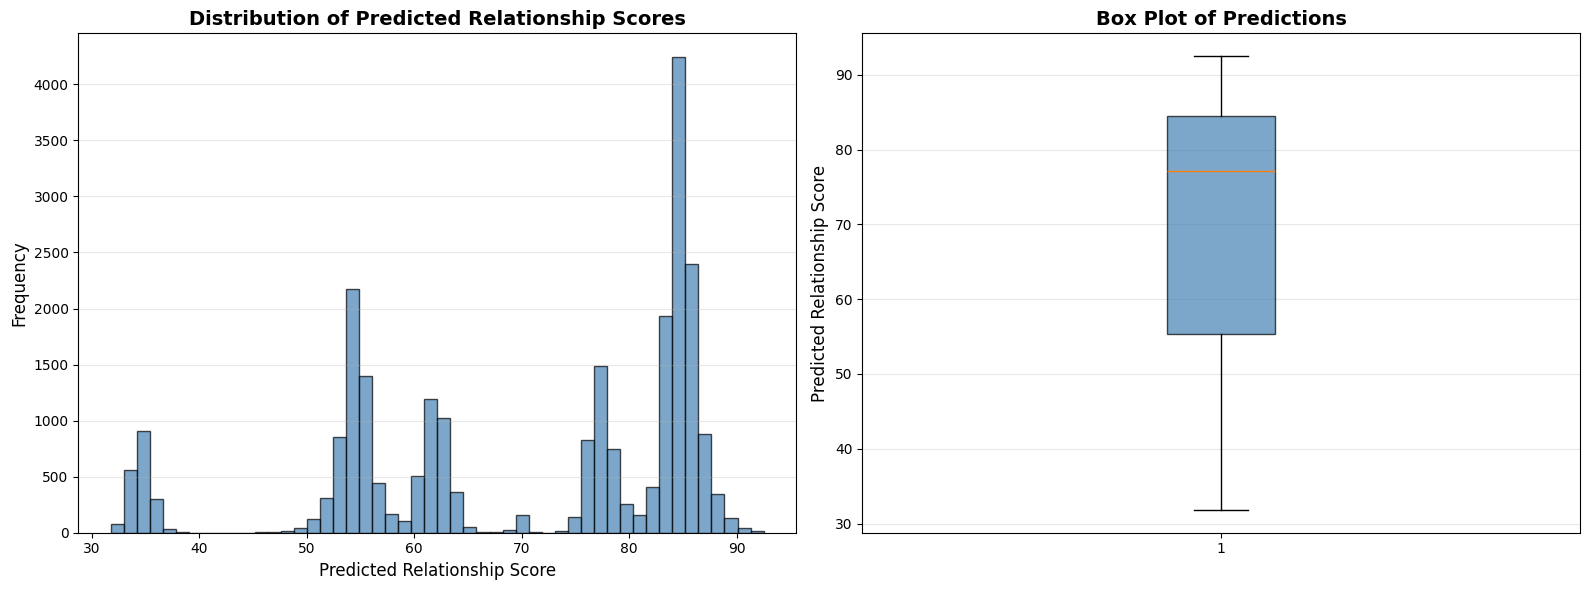


✓ Visualization complete: Prediction distribution


In [28]:
# Final Visualization: Compare health_score vs predicted_health_score
print("=" * 60)
print("FINAL VISUALIZATION: Actual vs Predicted Comparison")
print("=" * 60)

# Load data from healthscore_predictions.xlsx
data_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\healthscore_predictions.xlsx")
if not data_path.exists():
    print(f"⚠️  File not found: {data_path}")
    print("   Please run the prediction cells above first to generate the predictions file.")
    print("   This visualization cell requires the output from Step 6 (Saving Results).")
    comparison_df = None
else:
    comparison_df = pd.read_excel(data_path, engine='openpyxl')
    print(f"✓ Loaded data from: {data_path}")

print(f"✓ Loaded data from: {data_path}")
print(f"✓ Total rows: {len(comparison_df):,}")
print(f"✓ Columns: {list(comparison_df.columns)}")

# Check if health_score exists in the data
if comparison_df is None:
    print("\n❌ Cannot proceed with visualization - file not found.")
elif 'health_score' in comparison_df.columns and 'predicted_health_score' in comparison_df.columns:
    actual = comparison_df['health_score'].values
    predicted = comparison_df['predicted_health_score'].values
    
    # Calculate metrics
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    print(f"\n📊 Model Performance Metrics:")
    print(f"  R² Score:  {r2:.4f} ({r2*100:.2f}% variance explained)")
    print(f"  MAE:       {mae:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Scatter plot - Actual vs Predicted
    axes[0, 0].scatter(actual, predicted, alpha=0.5, s=20, color='steelblue', label='Data Points')
    axes[0, 0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], 
                   'r--', lw=2, label='Perfect Prediction Line')
    axes[0, 0].set_xlabel('Actual Relationship Score (health_score)', fontsize=12)
    axes[0, 0].set_ylabel('Predicted Relationship Score', fontsize=12)
    axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Plot 2: Residual plot
    residuals = actual - predicted
    axes[0, 1].scatter(predicted, residuals, alpha=0.5, s=20, color='coral')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Predicted Relationship Score', fontsize=12)
    axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Distribution comparison
    axes[1, 0].hist(actual, bins=50, alpha=0.6, label='Actual', color='steelblue', edgecolor='black')
    axes[1, 0].hist(predicted, bins=50, alpha=0.6, label='Predicted', color='coral', edgecolor='black')
    axes[1, 0].set_xlabel('Relationship Score', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Error distribution
    axes[1, 1].hist(residuals, bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    axes[1, 1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].set_title('Error Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete: 4 plots showing actual vs predicted comparison")
    
elif 'predicted_health_score' in comparison_df.columns:
    # Only predictions available, show distribution
    predicted = comparison_df['predicted_health_score'].values
    
    print("\n⚠️  Only predicted values available (no actual values for comparison)")
    print(f"\nPrediction Statistics:")
    print(f"  Min:  {predicted.min():.2f}")
    print(f"  Max:  {predicted.max():.2f}")
    print(f"  Mean: {predicted.mean():.2f}")
    print(f"  Std:  {predicted.std():.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].hist(predicted, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Predicted Relationship Score', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Predicted Relationship Scores', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].boxplot(predicted, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[1].set_ylabel('Predicted Relationship Score', fontsize=12)
    axes[1].set_title('Box Plot of Predictions', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete: Prediction distribution")
else:
    print("\n❌ Error: 'predicted_health_score' column not found in data")
    print(f"Available columns: {list(comparison_df.columns)}")
